# 08. Sparkov Capacity-Constrained Alerting

This notebook adds an explicit **operational capacity constraint** to the Sparkov fraud-detection project.

A fraud model can rank thousands of transactions, but a human investigation team may be able to review only a limited number of alerts each day.

The practical question is therefore not only:

> Which transactions look risky?

but also:

> Which transactions should be investigated when daily review capacity is limited?

## Main Research Question

> How much fraud, fraud amount, and proxy economic value can be captured under fixed daily alert capacities?

## Capacity Policies Compared

For daily capacities:

- Top-5
- Top-10
- Top-25
- Top-50

we compare two ranking rules.

### 1. Probability Top-K

Each day, alert the `K` transactions with the highest calibrated fraud probability.

### 2. Expected-Benefit Top-K

Each day:

1. calculate transaction-level expected benefit
2. keep only transactions with positive expected benefit
3. alert up to `K` transactions with the largest expected benefit

The second rule combines:

- calibrated fraud probability
- transaction amount
- assumed review cost
- assumed customer-friction cost
- assumed intervention effectiveness

## Metrics

We compare:

- average alerts per day
- total alerts
- Precision
- Recall
- Fraud Amount Recall
- proxy cost
- proxy cost reduction vs no alerts

## Important Interpretation

`amt` is treated as a proxy for potential transaction exposure.

It is **not** actual realized bank loss.

All cost parameters remain illustrative assumptions.

## Split Roles

- **Train** — model fitting
- **Calibration** — probability calibration
- **Validation** — alert-capacity analysis and selection
- **Test** — remains locked

## Test Set Lock

No Test prediction or Test metric is generated in this notebook.

## 1. Import Libraries and Create Output Folders

This notebook is independently runnable in Kaggle and recreates the earlier modeling pipeline before adding the capacity constraint.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
)

from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load and Clean the Sparkov Dataset

Expected Kaggle path:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

In [2]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

df = df.drop(
    columns=[
        c for c in df.columns
        if c.lower().startswith("unnamed")
    ],
    errors="ignore"
)

df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

df["merchant_clean"] = (
    df["merchant"]
    .astype(str)
    .str.replace(
        r"^fraud_",
        "",
        regex=True
    )
)

df = (
    df.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

assert df["unix_time"].is_monotonic_increasing

print("Shape:", df.shape)
print("Fraud rate:", df["is_fraud"].mean())

Shape: (1296675, 24)
Fraud rate: 0.005788651743883394


## 3. Recreate Current-Transaction Features

The capacity experiment uses the same current-transaction features as the earlier notebooks.

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 6371 * 2 * np.arcsin(np.sqrt(a))


df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype("int8")

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days
    / 365.25
)

df["distance_home_to_merchant_km"] = haversine_km(
    df["lat"],
    df["long"],
    df["merch_lat"],
    df["merch_long"]
)

print("Current-transaction features created.")

Current-transaction features created.


## 4. Recreate Leakage-Safe Past-Only Features

The same past-only framework from Notebook 04 is reused.

All historical statistics exclude the current transaction and use only earlier transaction information.

In [4]:
def add_past_only_features(data):
    data = (
        data.sort_values(
            ["unix_time", "trans_num"]
        )
        .reset_index(drop=True)
        .copy()
    )

    card_group = data.groupby(
        "cc_num",
        sort=False
    )

    data["card_tx_count_before"] = (
        card_group.cumcount()
    )

    data["card_has_history"] = (
        data["card_tx_count_before"] > 0
    ).astype("int8")

    data["card_prev_unix_time"] = (
        card_group["unix_time"].shift(1)
    )

    data["card_time_since_prev_hours"] = (
        data["unix_time"]
        - data["card_prev_unix_time"]
    ) / 3600.0

    data["_amt_sq"] = (
        data["amt"] ** 2
    )

    data["_card_amt_sum_before"] = (
        card_group["amt"].cumsum()
        - data["amt"]
    )

    data["_card_amt_sq_sum_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_amt_sq"].cumsum()
        - data["_amt_sq"]
    )

    previous_count = (
        data["card_tx_count_before"]
        .replace(0, np.nan)
    )

    data["card_amt_mean_before"] = (
        data["_card_amt_sum_before"]
        / previous_count
    )

    previous_second_moment = (
        data["_card_amt_sq_sum_before"]
        / previous_count
    )

    previous_variance = (
        previous_second_moment
        - data["card_amt_mean_before"] ** 2
    ).clip(lower=0)

    data["card_amt_std_before"] = (
        np.sqrt(previous_variance)
    )

    data["card_amt_ratio_to_mean"] = (
        data["amt"]
        / data[
            "card_amt_mean_before"
        ].replace(0, np.nan)
    )

    data["card_amt_zscore_before"] = (
        (
            data["amt"]
            - data["card_amt_mean_before"]
        )
        / data[
            "card_amt_std_before"
        ].replace(0, np.nan)
    )

    data["card_merchant_pair_count_before"] = (
        data.groupby(
            ["cc_num", "merchant_clean"],
            sort=False
        ).cumcount()
    )

    data["card_new_merchant"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_merchant_first_for_card"] = (
        data[
            "card_merchant_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_merchants_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_merchant_first_for_card"].cumsum()
        - data["_merchant_first_for_card"]
    )

    data["card_category_pair_count_before"] = (
        data.groupby(
            ["cc_num", "category"],
            sort=False
        ).cumcount()
    )

    data["card_new_category"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["_category_first_for_card"] = (
        data[
            "card_category_pair_count_before"
        ] == 0
    ).astype("int8")

    data["card_distinct_categories_before"] = (
        data.groupby(
            "cc_num",
            sort=False
        )["_category_first_for_card"].cumsum()
        - data["_category_first_for_card"]
    )

    merchant_group = data.groupby(
        "merchant_clean",
        sort=False
    )

    data["merchant_tx_count_before"] = (
        merchant_group.cumcount()
    )

    data["_merchant_amt_sum_before"] = (
        merchant_group["amt"].cumsum()
        - data["amt"]
    )

    merchant_previous_count = (
        data["merchant_tx_count_before"]
        .replace(0, np.nan)
    )

    data["merchant_amt_mean_before"] = (
        data["_merchant_amt_sum_before"]
        / merchant_previous_count
    )

    helper_cols = [
        "_amt_sq",
        "_card_amt_sum_before",
        "_card_amt_sq_sum_before",
        "_merchant_first_for_card",
        "_category_first_for_card",
        "_merchant_amt_sum_before",
    ]

    return data.drop(
        columns=helper_cols
    )


df = add_past_only_features(df)

print("Past-only features created.")

Past-only features created.


## 5. Recreate the Fixed Chronological Split

The project keeps the same design:

- Train: 60%
- Calibration: 15%
- Validation: 10%
- Test: 15%
- 24-hour total purge window around each boundary

The Test period remains locked.

In [5]:
TRAIN_RATIO = 0.60
CALIBRATION_RATIO = 0.15
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.15

PURGE_HOURS = 24
HALF_PURGE_SECONDS = int(
    (PURGE_HOURS / 2) * 3600
)

n = len(df)

train_boundary_idx = int(
    n * TRAIN_RATIO
)

calibration_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
    )
)

validation_boundary_idx = int(
    n * (
        TRAIN_RATIO
        + CALIBRATION_RATIO
        + VALIDATION_RATIO
    )
)

train_boundary = int(
    df.iloc[
        train_boundary_idx
    ]["unix_time"]
)

calibration_boundary = int(
    df.iloc[
        calibration_boundary_idx
    ]["unix_time"]
)

validation_boundary = int(
    df.iloc[
        validation_boundary_idx
    ]["unix_time"]
)

train = df[
    df["unix_time"]
    < (
        train_boundary
        - HALF_PURGE_SECONDS
    )
].copy()

calibration = df[
    (
        df["unix_time"]
        > (
            train_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            calibration_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

validation = df[
    (
        df["unix_time"]
        > (
            calibration_boundary
            + HALF_PURGE_SECONDS
        )
    )
    &
    (
        df["unix_time"]
        < (
            validation_boundary
            - HALF_PURGE_SECONDS
        )
    )
].copy()

test = df[
    df["unix_time"]
    > (
        validation_boundary
        + HALF_PURGE_SECONDS
    )
].copy()

assert (
    train["unix_time"].max()
    < calibration["unix_time"].min()
)

assert (
    calibration["unix_time"].max()
    < validation["unix_time"].min()
)

assert (
    validation["unix_time"].max()
    < test["unix_time"].min()
)

print({
    "train": len(train),
    "calibration": len(calibration),
    "validation": len(validation),
    "test": len(test),
})

{'train': 777050, 'calibration': 192249, 'validation': 128128, 'test': 193574}


## 6. Define the Feature Set

The same current + past-only feature set from Notebooks 05-07 is used.

In [6]:
current_numeric_features = [
    "amt",
    "city_pop",
    "age",
    "distance_home_to_merchant_km",
    "hour",
    "day_of_week",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

past_only_numeric_features = [
    "card_tx_count_before",
    "card_has_history",
    "card_time_since_prev_hours",
    "card_amt_mean_before",
    "card_amt_std_before",
    "card_amt_ratio_to_mean",
    "card_amt_zscore_before",
    "card_merchant_pair_count_before",
    "card_new_merchant",
    "card_distinct_merchants_before",
    "card_category_pair_count_before",
    "card_new_category",
    "card_distinct_categories_before",
    "merchant_tx_count_before",
    "merchant_amt_mean_before",
]

categorical_features = [
    "category",
    "merchant_clean",
    "state",
    "job",
]

numeric_features = (
    current_numeric_features
    + past_only_numeric_features
)

feature_cols = (
    numeric_features
    + categorical_features
)

TARGET = "is_fraud"

print("Total feature columns:", len(feature_cols))

Total feature columns: 30


## 7. Fit Train-Only Preprocessing

The preprocessing transformer is fitted on Train only.

Calibration and Validation are transformed using the Train-fitted rules.

In [7]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    ),
])

X_train = train[feature_cols]
y_train = (
    train[TARGET]
    .reset_index(drop=True)
)

X_calibration = calibration[feature_cols]
y_calibration = (
    calibration[TARGET]
    .reset_index(drop=True)
)

X_validation = validation[feature_cols]
y_validation = (
    validation[TARGET]
    .reset_index(drop=True)
)

X_train_encoded = (
    preprocessor.fit_transform(
        X_train
    )
)

X_calibration_encoded = (
    preprocessor.transform(
        X_calibration
    )
)

X_validation_encoded = (
    preprocessor.transform(
        X_validation
    )
)

print("Train shape:", X_train_encoded.shape)
print("Calibration shape:", X_calibration_encoded.shape)
print("Validation shape:", X_validation_encoded.shape)

Train shape: (777050, 30)
Calibration shape: (192249, 30)
Validation shape: (128128, 30)


## 8. Reproduce the Imbalance-Strategy Selection

Notebook 05 selected among:

- unweighted LightGBM
- weighted LightGBM
- 5:1 Train-only random undersampling

using Validation PR-AUC.

We reproduce that selection here so this notebook is independently runnable.

In [8]:
COMMON_PARAMS = dict(
    objective="binary",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

# Unweighted
unweighted_model = LGBMClassifier(
    **COMMON_PARAMS
)

unweighted_model.fit(
    X_train_encoded,
    y_train
)

unweighted_val_proba = (
    unweighted_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

# Weighted
train_legitimate = int(
    (y_train == 0).sum()
)

train_fraud = int(
    (y_train == 1).sum()
)

scale_pos_weight = (
    train_legitimate
    / train_fraud
)

weighted_model = LGBMClassifier(
    **COMMON_PARAMS,
    scale_pos_weight=scale_pos_weight
)

weighted_model.fit(
    X_train_encoded,
    y_train
)

weighted_val_proba = (
    weighted_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

# Undersampled
UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO = 5

rng = np.random.default_rng(
    SEED
)

fraud_positions = np.where(
    y_train.to_numpy() == 1
)[0]

legitimate_positions = np.where(
    y_train.to_numpy() == 0
)[0]

desired_legitimate_count = min(
    len(legitimate_positions),
    len(fraud_positions)
    * UNDERSAMPLE_NEGATIVE_TO_POSITIVE_RATIO
)

sampled_legitimate_positions = rng.choice(
    legitimate_positions,
    size=desired_legitimate_count,
    replace=False
)

undersample_positions = np.concatenate([
    fraud_positions,
    sampled_legitimate_positions,
])

rng.shuffle(
    undersample_positions
)

undersampled_model = LGBMClassifier(
    **COMMON_PARAMS
)

undersampled_model.fit(
    X_train_encoded[
        undersample_positions
    ],
    y_train.iloc[
        undersample_positions
    ]
)

undersampled_val_proba = (
    undersampled_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)

imbalance_selection = pd.DataFrame([
    {
        "strategy": "Unweighted LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                unweighted_val_proba
            )
        ),
    },
    {
        "strategy": "Weighted LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                weighted_val_proba
            )
        ),
    },
    {
        "strategy": "Undersampled LightGBM",
        "validation_pr_auc": (
            average_precision_score(
                y_validation,
                undersampled_val_proba
            )
        ),
    },
]).sort_values(
    "validation_pr_auc",
    ascending=False
).reset_index(drop=True)

display(imbalance_selection)

selected_strategy = (
    imbalance_selection.iloc[0]["strategy"]
)

print(
    "Selected underlying model:",
    selected_strategy
)

,strategy,validation_pr_auc
0,Unweighted LightGBM,0.928586
1,Undersampled LightGBM,0.923141
2,Weighted LightGBM,0.905961


Selected underlying model: Unweighted LightGBM


## 9. Reproduce the Probability-Calibration Selection

Notebook 06 fits Platt and isotonic calibrators on Calibration and selects the probability version using Validation Brier Score with Log Loss as a tie-breaker.

We reproduce that process here.

In [9]:
if selected_strategy == "Unweighted LightGBM":
    selected_model = unweighted_model

elif selected_strategy == "Weighted LightGBM":
    selected_model = weighted_model

elif selected_strategy == "Undersampled LightGBM":
    selected_model = undersampled_model

else:
    raise ValueError(
        "Unexpected selected strategy."
    )

calibration_raw_proba = (
    selected_model.predict_proba(
        X_calibration_encoded
    )[:, 1]
)

validation_raw_proba = (
    selected_model.predict_proba(
        X_validation_encoded
    )[:, 1]
)


def probability_to_logit(
    probability,
    eps=1e-8
):
    p = np.clip(
        np.asarray(probability),
        eps,
        1 - eps
    )

    return np.log(
        p / (1 - p)
    )


# Platt
platt_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

platt_model.fit(
    probability_to_logit(
        calibration_raw_proba
    ).reshape(-1, 1),
    y_calibration
)

validation_platt_proba = (
    platt_model.predict_proba(
        probability_to_logit(
            validation_raw_proba
        ).reshape(-1, 1)
    )[:, 1]
)

# Isotonic
isotonic_model = IsotonicRegression(
    out_of_bounds="clip"
)

isotonic_model.fit(
    calibration_raw_proba,
    y_calibration
)

validation_isotonic_proba = (
    isotonic_model.predict(
        validation_raw_proba
    )
)

calibration_selection = pd.DataFrame([
    {
        "method": "Raw",
        "brier": brier_score_loss(
            y_validation,
            validation_raw_proba
        ),
        "log_loss": log_loss(
            y_validation,
            np.clip(
                validation_raw_proba,
                1e-8,
                1 - 1e-8
            )
        ),
    },
    {
        "method": "Platt",
        "brier": brier_score_loss(
            y_validation,
            validation_platt_proba
        ),
        "log_loss": log_loss(
            y_validation,
            np.clip(
                validation_platt_proba,
                1e-8,
                1 - 1e-8
            )
        ),
    },
    {
        "method": "Isotonic",
        "brier": brier_score_loss(
            y_validation,
            validation_isotonic_proba
        ),
        "log_loss": log_loss(
            y_validation,
            np.clip(
                validation_isotonic_proba,
                1e-8,
                1 - 1e-8
            )
        ),
    },
]).sort_values(
    ["brier", "log_loss"],
    ascending=[True, True]
).reset_index(drop=True)

display(calibration_selection)

selected_calibration_method = (
    calibration_selection.iloc[0]["method"]
)

print(
    "Selected calibration method:",
    selected_calibration_method
)

if selected_calibration_method == "Raw":
    validation_probability = (
        validation_raw_proba
    )

elif selected_calibration_method == "Platt":
    validation_probability = (
        validation_platt_proba
    )

elif selected_calibration_method == "Isotonic":
    validation_probability = (
        validation_isotonic_proba
    )

else:
    raise ValueError(
        "Unexpected calibration method."
    )

,method,brier,log_loss
0,Isotonic,0.001310,0.005460
1,Platt,0.001317,0.005457
2,Raw,0.001521,0.006812


Selected calibration method: Isotonic


## 10. Recreate the Base Proxy-Cost Assumptions

Notebook 07 introduced several sensitivity scenarios.

This capacity notebook uses the **Base** scenario to compare alert-ranking policies.

These are illustrative assumptions, not observed bank costs.

In [10]:
BASE_COST = {
    "loss_rate": 0.50,
    "incident_cost": 10.0,
    "review_cost": 2.0,
    "friction_cost": 10.0,
    "intervention_effectiveness": 0.85,
}

pd.DataFrame(
    [BASE_COST]
)

,loss_rate,incident_cost,review_cost,friction_cost,intervention_effectiveness
0,0.500000,10.000000,2.000000,10.000000,0.850000


## 11. Calculate Transaction-Level Expected Benefit

For transaction \(i\):

\[
\text{Expected Prevented Loss}_i
=
p_i \times e \times
\left(
C_{\text{incident}}
+
r_{\text{loss}}A_i
\right)
\]

Expected alert cost is:

\[
C_{\text{review}}
+
(1-p_i)C_{\text{friction}}
\]

Then:

\[
\text{Expected Benefit}_i
=
\text{Expected Prevented Loss}_i
-
\text{Expected Alert Cost}_i
\]

Expected-benefit ranking therefore considers both fraud probability and transaction amount.

In [11]:
def expected_alert_benefit(
    probability,
    amount,
    loss_rate,
    incident_cost,
    review_cost,
    friction_cost,
    intervention_effectiveness,
):
    probability = np.asarray(
        probability
    )

    amount = np.asarray(
        amount
    )

    potential_loss = (
        incident_cost
        + loss_rate * amount
    )

    expected_prevented_loss = (
        probability
        * intervention_effectiveness
        * potential_loss
    )

    expected_alert_cost = (
        review_cost
        + (
            1 - probability
        )
        * friction_cost
    )

    return (
        expected_prevented_loss
        - expected_alert_cost
    )

## 12. Build the Validation Scoring Table

Each Validation transaction receives:

- selected calibrated probability
- transaction amount
- calendar date
- expected benefit

The calendar date is used to enforce daily alert capacity.

In [12]:
validation_scores = validation[
    [
        "trans_num",
        "trans_date_trans_time",
        "cc_num",
        "merchant_clean",
        "is_fraud",
        "amt",
    ]
].copy()

validation_scores[
    "probability"
] = validation_probability

validation_scores[
    "date"
] = (
    validation_scores[
        "trans_date_trans_time"
    ]
    .dt.date
)

validation_scores[
    "expected_benefit"
] = expected_alert_benefit(
    validation_scores[
        "probability"
    ].to_numpy(),
    validation_scores[
        "amt"
    ].to_numpy(),
    **BASE_COST
)

display(
    validation_scores.head()
)

,trans_num,trans_date_trans_time,cc_num,merchant_clean,is_fraud,amt,probability,date,expected_benefit
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,30234966027947,Hamill-Daugherty,0,64.480000,0.000000,2020-01-29,-12.000000
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,30044330818990,Herzog Ltd,0,105.470000,0.000000,2020-01-29,-12.000000
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,4464457352619,"Christiansen, Goyette and Schamberger",0,78.150000,0.000000,2020-01-29,-12.000000
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,377993105397617,Friesen-Stamm,0,64.900000,0.000000,2020-01-29,-12.000000
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,4169388510116,Prohaska-Murray,0,60.890000,0.000000,2020-01-29,-12.000000


## 13. Audit Daily Transaction Volume

Before applying Top-K policies, we inspect how many Validation transactions occur per day.

A daily capacity of 25 means something very different when a day contains 100 transactions versus 10,000 transactions.

In [13]:
daily_volume = (
    validation_scores
    .groupby(
        "date"
    )
    .agg(
        transactions=(
            "trans_num",
            "size"
        ),
        frauds=(
            "is_fraud",
            "sum"
        ),
        fraud_amount=(
            "amt",
            lambda s: s[
                validation_scores.loc[
                    s.index,
                    "is_fraud"
                ] == 1
            ].sum()
        ),
    )
    .reset_index()
)

display(
    daily_volume.describe(
        include="all"
    )
)

,date,transactions,frauds,fraud_amount
count,65,65.000000,65.000000,65.000000
unique,65,NaN,NaN,NaN
top,2020-01-29,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,"1,971.200000",12.969231,"7,016.493231"
std,NaN,703.662055,9.598127,"5,310.981869"
min,NaN,320.000000,0.000000,0.000000
25%,NaN,"1,393.000000",6.000000,"3,021.260000"
50%,NaN,"1,845.000000",11.000000,"6,028.100000"
75%,NaN,"2,411.000000",18.000000,"9,864.750000"


## 14. Define Daily Top-K Functions

### Probability Top-K

For each day:

- rank all transactions by calibrated probability
- alert the top `K`

### Expected-Benefit Top-K

For each day:

- remove transactions with non-positive expected benefit
- rank the remaining transactions by expected benefit
- alert up to `K`

The second rule may produce fewer than `K` alerts if fewer than `K` transactions have positive expected benefit.

In [14]:
def apply_daily_probability_top_k(
    data,
    k
):
    out = data.copy()

    out["alert"] = 0

    for _, group in out.groupby(
        "date",
        sort=False
    ):
        selected_index = (
            group.nlargest(
                min(
                    k,
                    len(group)
                ),
                "probability"
            )
            .index
        )

        out.loc[
            selected_index,
            "alert"
        ] = 1

    return out


def apply_daily_benefit_top_k(
    data,
    k
):
    out = data.copy()

    out["alert"] = 0

    for _, group in out.groupby(
        "date",
        sort=False
    ):
        eligible = group[
            group[
                "expected_benefit"
            ] > 0
        ]

        if len(eligible) == 0:
            continue

        selected_index = (
            eligible.nlargest(
                min(
                    k,
                    len(eligible)
                ),
                "expected_benefit"
            )
            .index
        )

        out.loc[
            selected_index,
            "alert"
        ] = 1

    return out

## 15. Define Proxy-Cost and Capacity Metrics

We calculate:

- total alerts
- average alerts per day
- median alerts per day
- maximum alerts on any day
- Precision
- Recall
- F1
- Fraud Amount Recall
- proxy cost components
- total proxy cost

This allows us to compare model quality and operational burden in the same table.

In [15]:
def calculate_proxy_cost_components(
    y_true,
    alert,
    amount,
    loss_rate,
    incident_cost,
    review_cost,
    friction_cost,
    intervention_effectiveness,
):
    y = np.asarray(y_true)
    alert = np.asarray(alert).astype(int)
    amount = np.asarray(amount)

    fraud = y == 1
    legitimate = y == 0
    alerted = alert == 1
    not_alerted = alert == 0

    false_negative = (
        fraud & not_alerted
    )

    true_positive = (
        fraud & alerted
    )

    false_positive = (
        legitimate & alerted
    )

    gross_fraud_loss = (
        incident_cost
        + loss_rate * amount
    )

    missed_fraud_cost = float(
        gross_fraud_loss[
            false_negative
        ].sum()
    )

    residual_detected_fraud_cost = float(
        (
            1
            - intervention_effectiveness
        )
        * gross_fraud_loss[
            true_positive
        ].sum()
    )

    total_review_cost = float(
        alerted.sum()
        * review_cost
    )

    total_friction_cost = float(
        false_positive.sum()
        * friction_cost
    )

    total_proxy_cost = (
        missed_fraud_cost
        + residual_detected_fraud_cost
        + total_review_cost
        + total_friction_cost
    )

    return {
        "missed_fraud_cost": (
            missed_fraud_cost
        ),
        "residual_detected_fraud_cost": (
            residual_detected_fraud_cost
        ),
        "review_cost": (
            total_review_cost
        ),
        "friction_cost": (
            total_friction_cost
        ),
        "total_proxy_cost": (
            total_proxy_cost
        ),
    }


def fraud_amount_recall(
    y_true,
    alert,
    amount
):
    y = np.asarray(
        y_true
    )

    alert = np.asarray(
        alert
    )

    amount = np.asarray(
        amount
    )

    total_fraud_amount = (
        amount[
            y == 1
        ].sum()
    )

    if total_fraud_amount == 0:
        return np.nan

    caught_fraud_amount = (
        amount[
            (y == 1)
            & (alert == 1)
        ].sum()
    )

    return (
        caught_fraud_amount
        / total_fraud_amount
    )


def evaluate_capacity_policy(
    policy_name,
    data,
    cfg
):
    y = (
        data["is_fraud"]
        .to_numpy()
    )

    alert = (
        data["alert"]
        .to_numpy()
    )

    amount = (
        data["amt"]
        .to_numpy()
    )

    daily_alerts = (
        data.groupby(
            "date"
        )["alert"]
        .sum()
    )

    costs = (
        calculate_proxy_cost_components(
            y,
            alert,
            amount,
            **cfg
        )
    )

    return {
        "policy": policy_name,
        "total_alerts": int(
            alert.sum()
        ),
        "avg_alerts_per_day": float(
            daily_alerts.mean()
        ),
        "median_alerts_per_day": float(
            daily_alerts.median()
        ),
        "max_alerts_per_day": int(
            daily_alerts.max()
        ),
        "precision": precision_score(
            y,
            alert,
            zero_division=0
        ),
        "recall": recall_score(
            y,
            alert,
            zero_division=0
        ),
        "f1": f1_score(
            y,
            alert,
            zero_division=0
        ),
        "fraud_amount_recall": (
            fraud_amount_recall(
                y,
                alert,
                amount
            )
        ),
        **costs,
    }

## 16. Create a No-Alert Reference

The no-alert policy provides a proxy economic reference.

It is not presented as a realistic operating strategy.

It simply shows the proxy cost of missing every fraud transaction while generating no review or friction cost.

In [16]:
no_alert_data = (
    validation_scores.copy()
)

no_alert_data[
    "alert"
] = 0

no_alert_metrics = (
    evaluate_capacity_policy(
        "No alerts",
        no_alert_data,
        BASE_COST
    )
)

no_alert_proxy_cost = (
    no_alert_metrics[
        "total_proxy_cost"
    ]
)

no_alert_metrics

{'policy': 'No alerts',
 'total_alerts': 0,
 'avg_alerts_per_day': 0.0,
 'median_alerts_per_day': 0.0,
 'max_alerts_per_day': 0,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'fraud_amount_recall': np.float64(0.0),
 'missed_fraud_cost': 236466.02999999997,
 'residual_detected_fraud_cost': 0.0,
 'review_cost': 0.0,
 'friction_cost': 0.0,
 'total_proxy_cost': 236466.02999999997}

## 17. Evaluate Daily Top-K Capacity Policies

We compare capacities:

- 5 alerts/day
- 10 alerts/day
- 25 alerts/day
- 50 alerts/day

for both ranking methods.

In [17]:
CAPACITY_VALUES = [
    5,
    10,
    25,
    50,
]

capacity_rows = []
daily_policy_frames = []

for k in CAPACITY_VALUES:

    probability_policy = (
        apply_daily_probability_top_k(
            validation_scores,
            k
        )
    )

    probability_metrics = (
        evaluate_capacity_policy(
            f"Probability Top-{k}",
            probability_policy,
            BASE_COST
        )
    )

    probability_metrics[
        "ranking_method"
    ] = "Probability"

    probability_metrics[
        "capacity_k"
    ] = k

    capacity_rows.append(
        probability_metrics
    )

    probability_daily = (
        probability_policy
        .groupby("date")
        .agg(
            alerts=(
                "alert",
                "sum"
            ),
            frauds=(
                "is_fraud",
                "sum"
            ),
            detected_frauds=(
                "is_fraud",
                lambda s: int(
                    (
                        s
                        * probability_policy.loc[
                            s.index,
                            "alert"
                        ]
                    ).sum()
                )
            ),
        )
        .reset_index()
    )

    probability_daily[
        "policy"
    ] = f"Probability Top-{k}"

    daily_policy_frames.append(
        probability_daily
    )

    benefit_policy = (
        apply_daily_benefit_top_k(
            validation_scores,
            k
        )
    )

    benefit_metrics = (
        evaluate_capacity_policy(
            f"Benefit Top-{k}",
            benefit_policy,
            BASE_COST
        )
    )

    benefit_metrics[
        "ranking_method"
    ] = "Expected benefit"

    benefit_metrics[
        "capacity_k"
    ] = k

    capacity_rows.append(
        benefit_metrics
    )

    benefit_daily = (
        benefit_policy
        .groupby("date")
        .agg(
            alerts=(
                "alert",
                "sum"
            ),
            frauds=(
                "is_fraud",
                "sum"
            ),
            detected_frauds=(
                "is_fraud",
                lambda s: int(
                    (
                        s
                        * benefit_policy.loc[
                            s.index,
                            "alert"
                        ]
                    ).sum()
                )
            ),
        )
        .reset_index()
    )

    benefit_daily[
        "policy"
    ] = f"Benefit Top-{k}"

    daily_policy_frames.append(
        benefit_daily
    )

capacity_results = pd.DataFrame(
    capacity_rows
)

capacity_results[
    "proxy_cost_reduction_vs_no_alert"
] = (
    no_alert_proxy_cost
    - capacity_results[
        "total_proxy_cost"
    ]
)

capacity_results[
    "proxy_cost_reduction_pct_vs_no_alert"
] = (
    capacity_results[
        "proxy_cost_reduction_vs_no_alert"
    ]
    / no_alert_proxy_cost
    * 100
)

daily_policy_summary = pd.concat(
    daily_policy_frames,
    ignore_index=True
)

display(
    capacity_results
)

,policy,total_alerts,avg_alerts_per_day,median_alerts_per_day,max_alerts_per_day,precision,recall,f1,fraud_amount_recall,missed_fraud_cost,residual_detected_fraud_cost,review_cost,friction_cost,total_proxy_cost,ranking_method,capacity_k,proxy_cost_reduction_vs_no_alert,proxy_cost_reduction_pct_vs_no_alert
0,Probability Top-5,325,5.000000,5.000000,5,0.867692,0.334520,0.482877,0.316185,"161,544.430000","11,238.240000",650.000000,430.000000,"173,862.670000",Probability,5,"62,603.360000",26.474568
1,Benefit Top-5,313,4.815385,5.000000,5,0.856230,0.317912,0.463668,0.507799,"117,989.635000","17,771.459250",626.000000,450.000000,"136,837.094250",Expected benefit,5,"99,628.935750",42.132452
2,Probability Top-10,650,10.000000,10.000000,10,0.738462,0.569395,0.643001,0.597054,"95,516.200000","21,142.474500","1,300.000000","1,700.000000","119,658.674500",Probability,10,"116,807.355500",49.397098
3,Benefit Top-10,565,8.692308,10.000000,10,0.800000,0.536180,0.642045,0.754499,"59,892.975000","26,485.958250","1,130.000000","1,130.000000","88,638.933250",Expected benefit,10,"147,827.096750",62.515151
4,Probability Top-25,1625,25.000000,25.000000,25,0.456000,0.879004,0.600486,0.930806,"16,798.625000","32,950.110750","3,250.000000","8,840.000000","61,838.735750",Probability,25,"174,627.294250",73.848787
5,Benefit Top-25,942,14.492308,15.000000,25,0.740977,0.827995,0.782073,0.947297,"13,468.230000","33,449.670000","1,884.000000","2,440.000000","51,241.900000",Expected benefit,25,"185,224.130000",78.330122
6,Probability Top-50,3250,50.000000,50.000000,50,0.251692,0.970344,0.399707,0.990489,"2,418.935000","35,107.064250","6,500.000000","24,320.000000","68,345.999250",Probability,50,"168,120.030750",71.096906
7,Benefit Top-50,1006,15.476923,15.000000,42,0.737575,0.880190,0.802596,0.969102,"8,055.825000","34,261.530750","2,012.000000","2,640.000000","46,969.355750",Expected benefit,50,"189,496.674250",80.136954


## 18. Select the Capacity Policy on Validation

For this synthetic project, we select the policy with the **lowest Base-scenario Validation proxy cost** among the candidate Top-K policies.

### Important real-world caveat

In a real institution, `K` may be fixed externally by staffing capacity.

If investigators can review at most 25 cases per day, the correct question is not "which K is optimal?" but "which ranking rule works best at K=25?"

Here, K is treated as a development sensitivity parameter because no real staffing constraint is available.

In [18]:
selected_capacity_policy = (
    capacity_results
    .sort_values(
        [
            "total_proxy_cost",
            "total_alerts",
        ],
        ascending=[
            True,
            True,
        ]
    )
    .iloc[0]
)

display(
    selected_capacity_policy.to_frame(
        "selected_value"
    )
)

,selected_value
policy,Benefit Top-50
total_alerts,1006
avg_alerts_per_day,15.476923
median_alerts_per_day,15.000000
max_alerts_per_day,42
precision,0.737575
recall,0.880190
f1,0.802596
fraud_amount_recall,0.969102
missed_fraud_cost,"8,055.825000"


## 19. Compare Probability Top-K and Benefit Top-K Directly

We create a compact paired comparison at each K.

This helps answer whether amount- and cost-aware ranking provides additional value beyond fraud probability alone.

In [19]:
paired_capacity_comparison = (
    capacity_results.pivot(
        index="capacity_k",
        columns="ranking_method",
        values=[
            "precision",
            "recall",
            "fraud_amount_recall",
            "total_proxy_cost",
            "avg_alerts_per_day",
        ]
    )
)

display(
    paired_capacity_comparison
)

precision                       recall              \
ranking_method Expected benefit Probability Expected benefit Probability   
capacity_k                                                                 
5                      0.856230    0.867692         0.317912    0.334520   
10                     0.800000    0.738462         0.536180    0.569395   
25                     0.740977    0.456000         0.827995    0.879004   
50                     0.737575    0.251692         0.880190    0.970344   

               fraud_amount_recall             total_proxy_cost  \
ranking_method    Expected benefit Probability Expected benefit   
capacity_k                                                        
5                         0.507799    0.316185   136,837.094250   
10                        0.754499    0.597054    88,638.933250   
25                        0.947297    0.930806    51,241.900000   
50                        0.969102    0.990489    46,969.355750   

                              avg_alerts_per_day              
ranking_method    Probability   Expected benefit Probability  
capacity_k                                                    
5              173,862.670000           4.815385    5.000000  
10             119,658.674500           8.692308   10.000000  
25              61,838.735750          14.492308   25.000000  
50              68,345.999250          15.476923   50.000000

## 20. Recall vs Daily Alert Capacity

This figure shows how fraud Recall changes as investigators are allowed to review more alerts per day.

Higher capacity should generally increase Recall, but the marginal improvement may diminish.

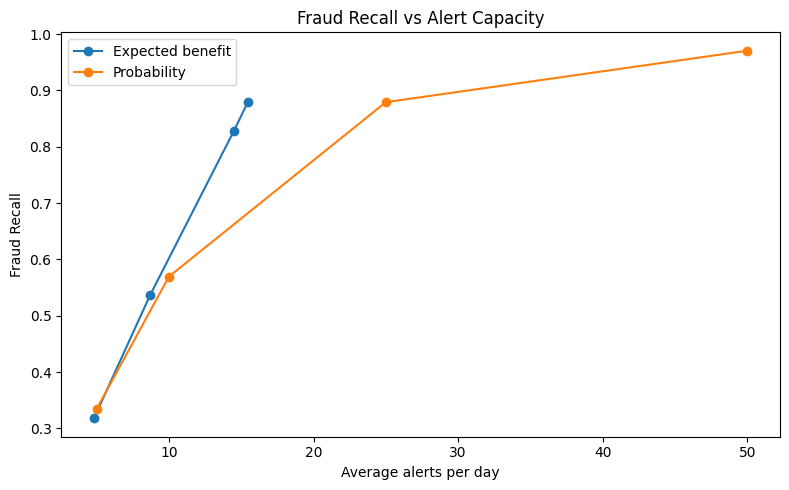

In [20]:
plt.figure(
    figsize=(8, 5)
)

for method, group in capacity_results.groupby(
    "ranking_method"
):
    group = group.sort_values(
        "capacity_k"
    )

    plt.plot(
        group[
            "avg_alerts_per_day"
        ],
        group[
            "recall"
        ],
        marker="o",
        label=method
    )

plt.xlabel(
    "Average alerts per day"
)

plt.ylabel(
    "Fraud Recall"
)

plt.title(
    "Fraud Recall vs Alert Capacity"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "recall_vs_alert_capacity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 21. Fraud Amount Recall vs Daily Alert Capacity

Fraud Amount Recall measures the share of total fraudulent transaction amount captured by alerts.

This metric can differ from ordinary Recall because not all fraud transactions have the same amount.

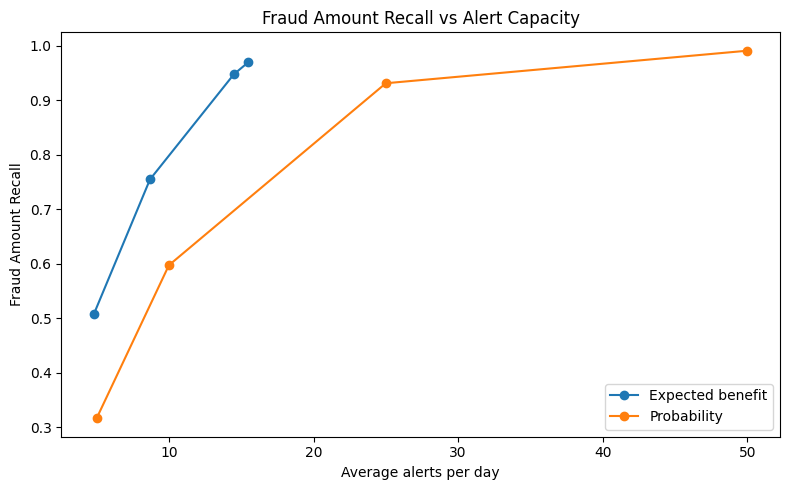

In [21]:
plt.figure(
    figsize=(8, 5)
)

for method, group in capacity_results.groupby(
    "ranking_method"
):
    group = group.sort_values(
        "capacity_k"
    )

    plt.plot(
        group[
            "avg_alerts_per_day"
        ],
        group[
            "fraud_amount_recall"
        ],
        marker="o",
        label=method
    )

plt.xlabel(
    "Average alerts per day"
)

plt.ylabel(
    "Fraud Amount Recall"
)

plt.title(
    "Fraud Amount Recall vs Alert Capacity"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "amount_recall_vs_capacity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 22. Precision vs Daily Alert Capacity

Precision often falls as more transactions are sent for review.

This figure makes the operational trade-off visible.

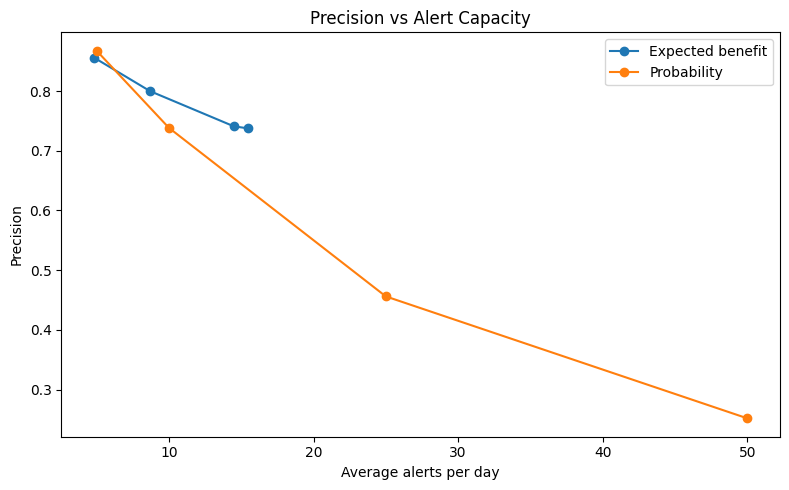

In [22]:
plt.figure(
    figsize=(8, 5)
)

for method, group in capacity_results.groupby(
    "ranking_method"
):
    group = group.sort_values(
        "capacity_k"
    )

    plt.plot(
        group[
            "avg_alerts_per_day"
        ],
        group[
            "precision"
        ],
        marker="o",
        label=method
    )

plt.xlabel(
    "Average alerts per day"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision vs Alert Capacity"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "precision_vs_alert_capacity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 23. Proxy Cost vs Daily Alert Capacity

More alerts are not always better.

Additional alerts can reduce missed-fraud cost but increase:

- review cost
- false-positive friction cost

The proxy-cost curve captures this trade-off under the Base assumptions.

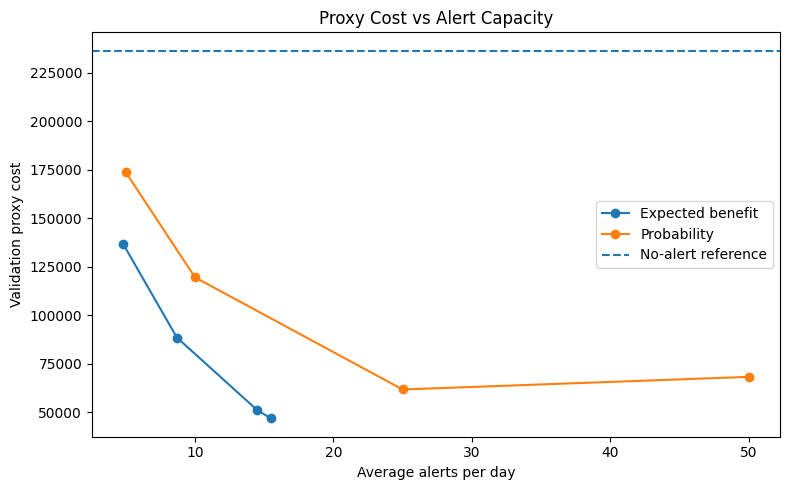

In [23]:
plt.figure(
    figsize=(8, 5)
)

for method, group in capacity_results.groupby(
    "ranking_method"
):
    group = group.sort_values(
        "capacity_k"
    )

    plt.plot(
        group[
            "avg_alerts_per_day"
        ],
        group[
            "total_proxy_cost"
        ],
        marker="o",
        label=method
    )

plt.axhline(
    no_alert_proxy_cost,
    linestyle="--",
    label="No-alert reference"
)

plt.xlabel(
    "Average alerts per day"
)

plt.ylabel(
    "Validation proxy cost"
)

plt.title(
    "Proxy Cost vs Alert Capacity"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "proxy_cost_vs_alert_capacity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 24. Inspect Daily Alert Utilization

Probability Top-K typically uses exactly K alerts on a day when at least K transactions exist.

Benefit Top-K may use fewer because transactions with non-positive expected benefit are not forced into the queue.

This difference is important:

> A capacity limit is a maximum, not a requirement to fill every slot.

In [24]:
daily_alert_utilization = (
    daily_policy_summary
    .groupby(
        "policy"
    )
    .agg(
        days=("date", "nunique"),
        mean_alerts=("alerts", "mean"),
        median_alerts=("alerts", "median"),
        min_alerts=("alerts", "min"),
        max_alerts=("alerts", "max"),
        total_detected_frauds=(
            "detected_frauds",
            "sum"
        ),
    )
    .reset_index()
)

display(
    daily_alert_utilization
)

,policy,days,mean_alerts,median_alerts,min_alerts,max_alerts,total_detected_frauds
0,Benefit Top-10,65,8.692308,10.000000,2,10,452
1,Benefit Top-25,65,14.492308,15.000000,2,25,698
2,Benefit Top-5,65,4.815385,5.000000,2,5,268
3,Benefit Top-50,65,15.476923,15.000000,2,42,742
4,Probability Top-10,65,10.000000,10.000000,10,10,480
5,Probability Top-25,65,25.000000,25.000000,25,25,741
6,Probability Top-5,65,5.000000,5.000000,5,5,282
7,Probability Top-50,65,50.000000,50.000000,50,50,818


## 25. Save Transaction-Level Decisions for the Selected Capacity Policy

We reconstruct the selected Validation policy and save its alert decisions.

This provides an auditable record of which transactions would have entered the investigation queue.

No Test decisions are generated.

In [25]:
selected_method = (
    selected_capacity_policy[
        "ranking_method"
    ]
)

selected_k = int(
    selected_capacity_policy[
        "capacity_k"
    ]
)

if selected_method == "Probability":
    selected_policy_frame = (
        apply_daily_probability_top_k(
            validation_scores,
            selected_k
        )
    )

elif selected_method == "Expected benefit":
    selected_policy_frame = (
        apply_daily_benefit_top_k(
            validation_scores,
            selected_k
        )
    )

else:
    raise ValueError(
        "Unexpected selected ranking method."
    )

selected_validation_decisions = (
    selected_policy_frame[
        [
            "trans_num",
            "trans_date_trans_time",
            "date",
            "cc_num",
            "merchant_clean",
            "is_fraud",
            "amt",
            "probability",
            "expected_benefit",
            "alert",
        ]
    ]
    .copy()
)

display(
    selected_validation_decisions.head()
)

,trans_num,trans_date_trans_time,date,cc_num,merchant_clean,is_fraud,amt,probability,expected_benefit,alert
973144,4b76605c3b0d1af2eb0c4d65471a8507,2020-01-29 03:06:41,2020-01-29,30234966027947,Hamill-Daugherty,0,64.480000,0.000000,-12.000000,0
973145,4bf9edc93a30609997e20b51463f235f,2020-01-29 03:08:10,2020-01-29,30044330818990,Herzog Ltd,0,105.470000,0.000000,-12.000000,0
973146,0f954e9f95faf5c8c2fee730fd15f33c,2020-01-29 03:09:14,2020-01-29,4464457352619,"Christiansen, Goyette and Schamberger",0,78.150000,0.000000,-12.000000,0
973147,77ae0fef10fe571fd75ce0bceac1cd68,2020-01-29 03:09:50,2020-01-29,377993105397617,Friesen-Stamm,0,64.900000,0.000000,-12.000000,0
973148,8b60b26dee5e2e4a7d212b02ace322c5,2020-01-29 03:10:44,2020-01-29,4169388510116,Prohaska-Murray,0,60.890000,0.000000,-12.000000,0


## 26. Save Capacity Configuration

The configuration records:

- selected underlying imbalance strategy
- selected calibration method
- cost assumptions
- candidate capacities
- selected ranking method
- selected K
- selection criterion

In [26]:
configuration_rows = [
    {
        "setting": (
            "selected_imbalance_strategy"
        ),
        "value": selected_strategy,
    },
    {
        "setting": (
            "selected_calibration_method"
        ),
        "value": (
            selected_calibration_method
        ),
    },
    {
        "setting": (
            "candidate_capacity_values"
        ),
        "value": ",".join(
            map(
                str,
                CAPACITY_VALUES
            )
        ),
    },
    {
        "setting": (
            "selected_ranking_method"
        ),
        "value": selected_method,
    },
    {
        "setting": (
            "selected_capacity_k"
        ),
        "value": selected_k,
    },
    {
        "setting": (
            "selection_criterion"
        ),
        "value": (
            "Lowest Base-scenario "
            "Validation proxy cost"
        ),
    },
    {
        "setting": (
            "no_alert_proxy_cost"
        ),
        "value": no_alert_proxy_cost,
    },
]

for key, value in BASE_COST.items():
    configuration_rows.append({
        "setting": (
            f"base_{key}"
        ),
        "value": value,
    })

capacity_configuration = pd.DataFrame(
    configuration_rows
)

display(
    capacity_configuration
)

,setting,value
0,selected_imbalance_strategy,Unweighted LightGBM
1,selected_calibration_method,Isotonic
2,candidate_capacity_values,"5,10,25,50"
3,selected_ranking_method,Expected benefit
4,selected_capacity_k,50
5,selection_criterion,Lowest Base-scenario Validation proxy cost
6,no_alert_proxy_cost,"236,466.030000"
7,base_loss_rate,0.500000
8,base_incident_cost,10.000000
9,base_review_cost,2.000000


## 27. Save Results

### Results

- `alert_capacity_results.csv`
- `alert_capacity_daily_summary.csv`
- `alert_capacity_daily_utilization.csv`
- `alert_capacity_configuration.csv`
- `alert_capacity_validation_decisions.csv`
- `alert_capacity_imbalance_selection_check.csv`
- `alert_capacity_calibration_selection_check.csv`

### Figures

- `recall_vs_alert_capacity.png`
- `amount_recall_vs_capacity.png`
- `precision_vs_alert_capacity.png`
- `proxy_cost_vs_alert_capacity.png`

In [27]:
capacity_results.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_results.csv",
    index=False
)

daily_policy_summary.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_daily_summary.csv",
    index=False
)

daily_alert_utilization.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_daily_utilization.csv",
    index=False
)

capacity_configuration.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_configuration.csv",
    index=False
)

selected_validation_decisions.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_validation_decisions.csv",
    index=False
)

imbalance_selection.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_imbalance_selection_check.csv",
    index=False
)

calibration_selection.to_csv(
    "/kaggle/working/results/"
    "alert_capacity_calibration_selection_check.csv",
    index=False
)

print("Results:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/results"
    )
):
    print("-", filename)

print("\nFigures:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/figures"
    )
):
    print("-", filename)

Results:
- alert_capacity_calibration_selection_check.csv
- alert_capacity_configuration.csv
- alert_capacity_daily_summary.csv
- alert_capacity_daily_utilization.csv
- alert_capacity_imbalance_selection_check.csv
- alert_capacity_results.csv
- alert_capacity_validation_decisions.csv

Figures:
- amount_recall_vs_capacity.png
- precision_vs_alert_capacity.png
- proxy_cost_vs_alert_capacity.png
- recall_vs_alert_capacity.png


## 28. How to Interpret the Results

### Increasing K

Larger K usually:

- increases Recall
- increases Fraud Amount Recall
- lowers Precision
- increases review workload

### Probability Top-K

This prioritizes the transactions most likely to be fraud.

### Benefit Top-K

This prioritizes transactions with the largest estimated economic benefit under the assumed proxy-cost model.

Therefore a somewhat lower-probability but high-amount transaction can outrank a higher-probability low-amount transaction.

### Selected K

The Validation-selected K should be treated as a project-development choice, not as a real staffing recommendation.

Actual capacity should come from operational staffing constraints.

## 29. Why Capacity-Constrained Evaluation Matters

A threshold-based fraud model can generate an unpredictable number of alerts.

A daily Top-K policy creates a direct connection between model output and analyst workload.

This makes the project closer to an operational fraud queue:

- the model ranks transactions
- the policy applies a capacity limit
- investigators receive only the highest-priority cases

That distinction is important because a model can have excellent PR-AUC but still be impractical if it creates too many alerts.

## 30. Leakage and Methodology Notes

### Train

Used to fit preprocessing and the underlying fraud model.

### Calibration

Used to fit probability calibrators.

### Validation

Used to:

- select imbalance strategy
- select calibration method
- compare capacity policies
- select the development-stage K/ranking rule

### Test

Remains untouched.

### Daily grouping

Capacity is enforced separately for each calendar day in Validation.

### Benefit positivity

Benefit Top-K does not force the queue to contain K alerts when fewer than K transactions have positive estimated benefit.

### Cost assumptions

Expected benefit depends on illustrative cost assumptions and should not be presented as observed economic value.

## 31. Limitations

### Synthetic dataset

Sparkov is synthetic, so capacity results reflect the simulator.

### Illustrative staffing levels

Top-5, Top-10, Top-25, and Top-50 are sensitivity levels, not observed analyst-team capacities.

### Illustrative economics

Expected-benefit ranking depends on assumed:

- loss rate
- incident cost
- review cost
- customer-friction cost
- intervention effectiveness

### Validation reuse

Validation is used repeatedly across development notebooks.

This is acceptable for the development workflow, but it increases the importance of keeping the final Test set untouched.

### One-day capacity window

This notebook uses calendar-day limits.

Real operations may use hourly shifts, queues, service-level agreements, or region-specific teams.

## Conclusion

This notebook introduced explicit operational alert capacity.

The workflow:

1. recreated the fixed temporal split
2. recreated the selected fraud model and probability calibration
3. calculated transaction-level expected benefit
4. defined daily Top-K alert rules
5. compared probability ranking with expected-benefit ranking
6. evaluated Top-5, Top-10, Top-25, and Top-50 capacities
7. measured Precision, Recall, Fraud Amount Recall, workload, and proxy cost
8. selected a development-stage capacity policy using Validation proxy cost
9. saved transaction-level and daily decision outputs
10. kept the Test period untouched

## Next Notebook

`09_sparkov_temporal_drift.ipynb`

The next step will evaluate how fraud prevalence and model performance change over time.

The analysis will compare:

- a frozen model
- an expanding-window retraining strategy

using post-Train development periods while preserving the final Test lock.